# DATA266 Lab 1 — Task 1: GPT-Style LLM From Scratch

**Student:** Pramod Dindukurthi  
**Course:** DATA 266 — Generative AI  
**Dataset:** TinyStories  
**Goal:** Complete Task 1 in a single GPU-lab notebook.

This notebook covers the full Task 1 workflow:

- character-level tokenization with custom `char_to_idx` / `idx_to_char`
- own 100K train / 10K validation split
- GPT-style Transformer built from scratch
- manual causal multi-head self-attention
- token + positional embeddings
- residual connections, LayerNorm, feed-forward network
- cross-entropy training
- LR warm-up + cosine scheduling
- minimum 10 epochs
- checkpoint/resume
- train/validation loss curves
- greedy + temperature generation
- all required Task 1 metrics
- failure-analysis template
- results export

### GPU-lab model configuration

This notebook defaults to a fast 2-hour-target profile for an RTX 4090:

- context length: **128**
- embedding dim: **256**
- heads: **8**
- blocks: **4**
- FFN dim: **1024**
- batch size: **128**
- gradient accumulation: **1**
- epochs: **10**
- AMP: enabled
- TF32 enabled

If VRAM is tight, reduce `batch_size` first.

## 1. Imports and environment

In [2]:
%pip install -q datasets pandas matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, sys, math, time, json, random, platform, logging
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime:", torch.version.cuda)

Python: 3.10.13
PyTorch: 2.1.2
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
CUDA runtime: 12.1


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [2]:
@dataclass
class Config:
    seed: int = 42

    hf_dataset: str = "roneneldan/TinyStories"
    train_stories: int = 100_000
    val_stories: int = 10_000

    block_size: int = 128
    d_model: int = 256
    n_heads: int = 8
    n_layers: int = 4
    ffn_dim: int = 1024
    dropout: float = 0.10

    batch_size: int = 128
    grad_accum_steps: int = 1
    epochs: int = 10
    learning_rate: float = 4e-4
    min_lr_ratio: float = 0.10
    weight_decay: float = 0.10
    betas: tuple = (0.9, 0.95)
    grad_clip: float = 1.0
    warmup_ratio: float = 0.05
    num_workers: int = 6
    use_amp: bool = True

    # non-overlapping fixed-length sequences
    stride: int = 128

    checkpoint_every_steps: int = 1000
    keep_periodic_every_steps: int = 5000

    eval_batches: int = 100
    generation_max_new_tokens: int = 500
    temperature: float = 0.8
    top_k: int = 40

CFG = Config()

OUTPUT_ROOT = Path.cwd() / "task1_llm" / "Pramod_Dindukurthi"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
OUTPUT_DIR = OUTPUT_ROOT / "outputs"
PROCESSED_DIR = OUTPUT_ROOT / "data_processed"
LOG_DIR = OUTPUT_ROOT / "logs"

for p in [CHECKPOINT_DIR, OUTPUT_DIR, PROCESSED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

with open(OUTPUT_ROOT / "config.json", "w") as f:
    json.dump(asdict(CFG), f, indent=2, default=str)

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print(json.dumps(asdict(CFG), indent=2, default=str))

OUTPUT_ROOT: /app/task1_llm/Pramod_Dindukurthi
{
  "seed": 42,
  "hf_dataset": "roneneldan/TinyStories",
  "train_stories": 100000,
  "val_stories": 10000,
  "block_size": 128,
  "d_model": 256,
  "n_heads": 8,
  "n_layers": 4,
  "ffn_dim": 1024,
  "dropout": 0.1,
  "batch_size": 128,
  "grad_accum_steps": 1,
  "epochs": 10,
  "learning_rate": 0.0004,
  "min_lr_ratio": 0.1,
  "weight_decay": 0.1,
  "betas": [
    0.9,
    0.95
  ],
  "grad_clip": 1.0,
  "warmup_ratio": 0.05,
  "num_workers": 6,
  "use_amp": true,
  "stride": 128,
  "checkpoint_every_steps": 1000,
  "keep_periodic_every_steps": 5000,
  "eval_batches": 100,
  "generation_max_new_tokens": 500,
  "temperature": 0.8,
  "top_k": 40
}


## 3. Seeds + hardware manifest

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hardware_manifest = {
    "python": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "pytorch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_runtime": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "gpu_count": torch.cuda.device_count() if torch.cuda.is_available() else 0,
}

with open(OUTPUT_ROOT / "hardware_manifest.json", "w") as f:
    json.dump(hardware_manifest, f, indent=2)

hardware_manifest

{'python': '3.10.13 (main, Sep 11 2023, 13:44:35) [GCC 11.2.0]',
 'platform': 'Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.31',
 'processor': 'x86_64',
 'pytorch': '2.1.2',
 'cuda_available': True,
 'cuda_runtime': '12.1',
 'gpu': 'NVIDIA GeForce RTX 4090',
 'gpu_count': 1}

## 4. Load TinyStories and create your own 100K / 10K split

In [4]:
dataset = load_dataset(CFG.hf_dataset)

print(dataset)
for split_name in dataset.keys():
    print(split_name, len(dataset[split_name]), dataset[split_name].column_names)

pool = dataset["train"].shuffle(seed=CFG.seed)
needed = CFG.train_stories + CFG.val_stories
assert len(pool) >= needed

train_rows = pool.select(range(CFG.train_stories))
val_rows = pool.select(range(CFG.train_stories, needed))

print("Train stories:", len(train_rows))
print("Validation stories:", len(val_rows))
print(train_rows[0]["text"][:800])

Generating validation split: 100%|██████████| 21990/21990 [00:00<00:00, 812208.25 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})
train 2119719 ['text']
validation 21990 ['text']
Train stories: 100000
Validation stories: 10000
Tim and Mia like to play in the park. They see a big club on the ground. It is brown and long and heavy.

"Look, a club!" Tim says. "I can lift it!"

He tries to lift the club, but it is too tough. He falls down and drops the club.

"Ouch!" he says. "That hurt!"

Mia laughs. She is not mean, she just thinks it is funny.

"Let me try!" she says. "I can balance it!"

She picks up the club and puts it on her head. She walks slowly and carefully. She does not fall down.

"Wow!" Tim says. "You are good at balancing!"

"Thank you!" Mia says. "It is fun!"

They take turns balancing the club on their heads, arms, and legs. They have a lot of fun with the club. They are happy and proud. They are good friends.


## 5. Character vocabulary

In [5]:
def build_vocab(rows):
    chars = set()
    for text in tqdm(rows["text"], desc="Building vocabulary"):
        chars.update(text)
    chars.add("\n")
    chars = sorted(chars)
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for ch, i in char_to_idx.items()}
    return chars, char_to_idx, idx_to_char

chars, char_to_idx, idx_to_char = build_vocab(train_rows)
vocab_size = len(chars)

print("Vocabulary size:", vocab_size)
print(repr("".join(chars)))

with open(PROCESSED_DIR / "vocab.json", "w", encoding="utf-8") as f:
    json.dump({"chars": chars, "char_to_idx": char_to_idx},
              f, ensure_ascii=False, indent=2)

Building vocabulary: 100%|██████████| 100000/100000 [00:02<00:00, 43983.11it/s]

Vocabulary size: 113
'\t\n !"$%&\'()*+,-./0123456789:;=>?ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]_`abcdefghijklmnopqrstuvwxyz\xa0¡¦¨©ª¯±²´ÂÃÑâîœŠ˜–“”‹€™'


## 6. Encode and cache the selected stories

In [6]:
def encode_rows(rows, char_to_idx, cache_path):
    cache_path = Path(cache_path)
    if cache_path.exists():
        print("Loading cached encoding:", cache_path)
        return torch.load(cache_path, map_location="cpu")

    parts = []
    sep = torch.tensor([char_to_idx["\n"], char_to_idx["\n"]], dtype=torch.int16)

    for text in tqdm(rows["text"], desc=f"Encoding {cache_path.stem}"):
        ids = [char_to_idx[c] for c in text if c in char_to_idx]
        if ids:
            parts.append(torch.tensor(ids, dtype=torch.int16))
            parts.append(sep)

    encoded = torch.cat(parts)
    torch.save(encoded, cache_path)
    print(f"Saved {len(encoded):,} characters -> {cache_path}")
    return encoded

train_ids = encode_rows(train_rows, char_to_idx, PROCESSED_DIR / "train_ids.pt")
val_ids = encode_rows(val_rows, char_to_idx, PROCESSED_DIR / "val_ids.pt")

print("Train characters:", f"{len(train_ids):,}")
print("Validation characters:", f"{len(val_ids):,}")

Loading cached encoding: /app/task1_llm/Pramod_Dindukurthi/data_processed/train_ids.pt
Loading cached encoding: /app/task1_llm/Pramod_Dindukurthi/data_processed/val_ids.pt
Train characters: 89,601,490
Validation characters: 8,951,983


## 7. Fixed-length autoregressive Dataset + DataLoaders

In [7]:
class CharSequenceDataset(Dataset):
    def __init__(self, encoded, block_size, stride):
        self.encoded = encoded
        self.block_size = block_size
        self.stride = stride
        self.n = max(0, (len(encoded) - (block_size + 1)) // stride + 1)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        start = idx * self.stride
        chunk = self.encoded[start:start + self.block_size + 1].long()
        return chunk[:-1], chunk[1:]

train_ds = CharSequenceDataset(train_ids, CFG.block_size, CFG.stride)
val_ds = CharSequenceDataset(val_ids, CFG.block_size, CFG.stride)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=CFG.num_workers > 0,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=CFG.num_workers > 0,
    drop_last=False,
)

print("Train sequences:", len(train_ds))
print("Validation sequences:", len(val_ds))
print("Train batches/epoch:", len(train_loader))

xb, yb = next(iter(train_loader))
print("x:", xb.shape, "y:", yb.shape)

Train sequences: 700011
Validation sequences: 69937
Train batches/epoch: 5468
x: torch.Size([128, 128]) y: torch.Size([128, 128])


# 8. GPT from scratch

The attention implementation below is manual and does **not** use:

- `nn.MultiheadAttention`
- `nn.Transformer`
- `nn.TransformerEncoder`
- `scaled_dot_product_attention`

In [17]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = self.causal_mask[:, :, :T, :T]
        scores = scores.masked_fill(~mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(out))


class FeedForward(nn.Module):
    def __init__(self, d_model, ffn_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, ffn_dim, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class CharGPT(nn.Module):
    def __init__(self, vocab_size, cfg):
        super().__init__()
        self.block_size = cfg.block_size

        self.token_embedding = nn.Embedding(vocab_size, cfg.d_model)
        self.position_embedding = nn.Embedding(cfg.block_size, cfg.d_model)
        self.dropout = nn.Dropout(cfg.dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                cfg.d_model,
                cfg.n_heads,
                cfg.ffn_dim,
                cfg.block_size,
                cfg.dropout
            )
            for _ in range(cfg.n_layers)
        ])

        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, vocab_size, bias=False)

        # Weight tying
        self.lm_head.weight = self.token_embedding.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block size {self.block_size}")

        pos = torch.arange(T, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(pos)[None, :, :]
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1)
            )

        return logits, loss

model = CharGPT(vocab_size, CFG).to(device)

param_count = sum(p.numel() for p in model.parameters())
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Total parameters: {param_count:,}")
print(f"Trainable parameters: {trainable_count:,}")

CharGPT(
  (token_embedding): Embedding(113, 256)
  (position_embedding): Embedding(128, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=False)
        (k_proj): Linear(in_features=256, out_features=256, bias=False)
        (v_proj): Linear(in_features=256, out_features=256, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)

## 9. Optimizer + warm-up/cosine decay

In [18]:
updates_per_epoch = math.ceil(len(train_loader) / CFG.grad_accum_steps)
total_update_steps = updates_per_epoch * CFG.epochs
warmup_steps = max(1, int(total_update_steps * CFG.warmup_ratio))

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.learning_rate,
    betas=CFG.betas,
    weight_decay=CFG.weight_decay,
)

def lr_lambda(step):
    if step < warmup_steps:
        return max(1e-8, step / warmup_steps)

    progress = (step - warmup_steps) / max(1, total_update_steps - warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))
    return CFG.min_lr_ratio + (1.0 - CFG.min_lr_ratio) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

amp_enabled = CFG.use_amp and device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

print("Updates/epoch:", updates_per_epoch)
print("Total updates:", total_update_steps)
print("Warm-up steps:", warmup_steps)
print("AMP enabled:", amp_enabled)

Updates/epoch: 5468
Total updates: 54680
Warm-up steps: 2734
AMP enabled: True


## 10. Checkpoint / resume utilities

In [15]:
# 10. Checkpoint / resume utilities

def get_rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }

    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()

    return state


def set_rng_state(state):
    if not state:
        return

    random.setstate(state["python"])
    np.random.set_state(state["numpy"])

    # CPU RNG state must be a CPU ByteTensor
    torch_state = state["torch"].detach().cpu().to(torch.uint8)
    torch.set_rng_state(torch_state)

    # CUDA RNG states also need to be restored correctly
    if torch.cuda.is_available() and "cuda" in state:
        cuda_states = [
            s.detach().cpu().to(torch.uint8)
            for s in state["cuda"]
        ]
        torch.cuda.set_rng_state_all(cuda_states)


def atomic_torch_save(obj, path):
    path = Path(path)

    # Save to a temporary file first, then replace the real checkpoint.
    # This reduces the chance of leaving a corrupted checkpoint if saving
    # is interrupted.
    tmp = path.with_suffix(path.suffix + ".tmp")

    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_checkpoint(
    path,
    epoch,
    batch_in_epoch,
    global_step,
    history,
    best_val_loss
):
    payload = {
        "epoch": epoch,
        "batch_in_epoch": batch_in_epoch,
        "global_step": global_step,

        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),

        "history": history,
        "best_val_loss": best_val_loss,
        "config": asdict(CFG),

        # Save RNG states so resume is more reproducible
        "rng_state": get_rng_state(),
    }

    atomic_torch_save(payload, path)


def load_checkpoint(path):
    # Load everything onto CPU first so the CPU RNG state remains valid
    ckpt = torch.load(path, map_location="cpu")

    # Restore model
    model.load_state_dict(ckpt["model_state_dict"])

    # Restore optimizer
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    # Move optimizer state tensors back to the active device
    # because checkpoint was loaded on CPU.
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)

    # Restore LR scheduler
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    # Restore AMP scaler
    if "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])

    # Restore RNG states
    set_rng_state(ckpt.get("rng_state"))

    print(
        f"Loaded checkpoint: epoch={ckpt['epoch']}, "
        f"batch={ckpt['batch_in_epoch']}, "
        f"global_step={ckpt['global_step']}"
    )

    return ckpt

## 11. Evaluation helper

In [11]:
@torch.no_grad()
def evaluate(model, loader, max_batches=None):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits, loss = model(x, y)

        n = y.numel()
        total_loss += loss.item() * n
        total_correct += (logits.argmax(dim=-1) == y).sum().item()
        total_tokens += n

    return {
        "loss": total_loss / total_tokens,
        "accuracy": total_correct / total_tokens,
        "tokens": total_tokens,
    }

# 12. Smoke test

Run this once before full training.  
**After it passes, rerun Cells 8 and 9** so the real experiment starts from fresh weights.

In [16]:
def smoke_test():
    model.train()
    x, y = next(iter(train_loader))
    x = x[:4].to(device)
    y = y[:4].to(device)

    optimizer.zero_grad(set_to_none=True)

    with torch.cuda.amp.autocast(enabled=amp_enabled):
        logits, loss = model(x, y)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)

    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    smoke_path = CHECKPOINT_DIR / "smoke_checkpoint.pt"
    save_checkpoint(
        smoke_path,
        epoch=0,
        batch_in_epoch=0,
        global_step=1,
        history=[],
        best_val_loss=float("inf")
    )

    _ = load_checkpoint(smoke_path)

    print("Logits shape:", tuple(logits.shape))
    print("Loss:", float(loss))
    print("Gradient norm:", float(grad_norm))
    print("SMOKE TEST PASSED")

smoke_test()

Loaded checkpoint: epoch=0, batch=0, global_step=1
Logits shape: (4, 128, 113)
Loss: 4.841819763183594
Gradient norm: 6.6713032722473145
SMOKE TEST PASSED


# 13. Full training — 10 epochs

### Resume after interruption

If training is interrupted:

1. rerun setup/data/model/optimizer cells
2. set `RESUME = True`
3. run this cell again

The notebook restores model, optimizer, scheduler, scaler, step count, history, and RNG state.

In [19]:
RESUME = False

LATEST_CKPT = CHECKPOINT_DIR / "latest_checkpoint.pt"
BEST_CKPT = CHECKPOINT_DIR / "best_model.pt"

history = []
best_val_loss = float("inf")
start_epoch = 0
resume_batch = 0
global_step = 0

logger = logging.getLogger("task1_train")
logger.setLevel(logging.INFO)
logger.handlers.clear()

fh = logging.FileHandler(LOG_DIR / "training_log.txt", mode="a")
fh.setFormatter(logging.Formatter("%(asctime)s | %(message)s"))
logger.addHandler(fh)

sh = logging.StreamHandler()
sh.setFormatter(logging.Formatter("%(message)s"))
logger.addHandler(sh)

if RESUME and LATEST_CKPT.exists():
    ckpt = load_checkpoint(LATEST_CKPT)
    start_epoch = ckpt["epoch"]
    resume_batch = ckpt["batch_in_epoch"] + 1
    global_step = ckpt["global_step"]
    history = ckpt.get("history", [])
    best_val_loss = ckpt.get("best_val_loss", float("inf"))
    logger.info(
        f"RESUME epoch={start_epoch} batch={resume_batch} step={global_step}"
    )

training_start_time = time.time()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

optimizer.zero_grad(set_to_none=True)

for epoch in range(start_epoch, CFG.epochs):
    model.train()

    epoch_loss_sum = 0.0
    epoch_tokens = 0
    epoch_correct = 0
    epoch_start = time.time()
    grad_norms = []
    nan_count = 0

    pbar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {epoch+1}/{CFG.epochs}"
    )

    for batch_idx, (x, y) in pbar:
        if epoch == start_epoch and batch_idx < resume_batch:
            continue

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits, loss = model(x, y)
            loss_for_backward = loss / CFG.grad_accum_steps

        if not torch.isfinite(loss):
            nan_count += 1
            logger.warning(
                f"Non-finite loss: epoch={epoch+1}, batch={batch_idx}"
            )
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler.scale(loss_for_backward).backward()

        n_tokens = y.numel()
        epoch_loss_sum += loss.item() * n_tokens
        epoch_tokens += n_tokens
        epoch_correct += (logits.argmax(dim=-1) == y).sum().item()

        do_update = (
            ((batch_idx + 1) % CFG.grad_accum_steps == 0)
            or (batch_idx + 1 == len(train_loader))
        )

        if do_update:
            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), CFG.grad_clip
            )
            grad_norm_value = float(grad_norm)

            if math.isfinite(grad_norm_value):
                grad_norms.append(grad_norm_value)
            else:
                nan_count += 1

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            global_step += 1

            if global_step % CFG.checkpoint_every_steps == 0:
                save_checkpoint(
                    LATEST_CKPT,
                    epoch,
                    batch_idx,
                    global_step,
                    history,
                    best_val_loss,
                )
                logger.info(
                    f"Checkpoint saved: epoch={epoch+1} "
                    f"batch={batch_idx} step={global_step}"
                )

            if (
                CFG.keep_periodic_every_steps > 0
                and global_step % CFG.keep_periodic_every_steps == 0
            ):
                save_checkpoint(
                    CHECKPOINT_DIR / f"checkpoint_step_{global_step:07d}.pt",
                    epoch,
                    batch_idx,
                    global_step,
                    history,
                    best_val_loss,
                )

        running_loss = epoch_loss_sum / max(epoch_tokens, 1)
        running_acc = epoch_correct / max(epoch_tokens, 1)

        pbar.set_postfix(
            loss=f"{running_loss:.4f}",
            acc=f"{running_acc:.3f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            step=global_step,
        )

    train_loss = epoch_loss_sum / epoch_tokens
    train_acc = epoch_correct / epoch_tokens

    val_metrics = evaluate(
        model,
        val_loader,
        max_batches=CFG.eval_batches
    )

    epoch_seconds = time.time() - epoch_start
    tokens_per_sec = epoch_tokens / epoch_seconds

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "generalization_gap": val_metrics["loss"] - train_loss,
        "perplexity": math.exp(min(val_metrics["loss"], 20)),
        "bits_per_character": val_metrics["loss"] / math.log(2),
        "mean_grad_norm": float(np.mean(grad_norms)) if grad_norms else np.nan,
        "max_grad_norm": float(np.max(grad_norms)) if grad_norms else np.nan,
        "nan_count": nan_count,
        "learning_rate": optimizer.param_groups[0]["lr"],
        "epoch_seconds": epoch_seconds,
        "train_tokens_per_sec": tokens_per_sec,
        "global_step": global_step,
    }
    history.append(row)

    pd.DataFrame(history).to_csv(
        OUTPUT_DIR / "training_history.csv",
        index=False
    )

    logger.info(
        f"EPOCH {epoch+1}/{CFG.epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"ppl={row['perplexity']:.2f} | "
        f"BPC={row['bits_per_character']:.3f} | "
        f"grad={row['mean_grad_norm']:.3f} | "
        f"tok/s={tokens_per_sec:,.0f} | "
        f"time={epoch_seconds/60:.1f}min"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        save_checkpoint(
            BEST_CKPT,
            epoch,
            len(train_loader)-1,
            global_step,
            history,
            best_val_loss,
        )
        logger.info(f"New best val loss: {best_val_loss:.4f}")

    # Epoch-boundary latest checkpoint. batch=-1 means next run starts at batch 0.
    save_checkpoint(
        LATEST_CKPT,
        epoch + 1,
        -1,
        global_step,
        history,
        best_val_loss,
    )

    resume_batch = 0

total_training_time = time.time() - training_start_time
peak_memory_mb = (
    torch.cuda.max_memory_allocated() / (1024**2)
    if torch.cuda.is_available()
    else 0.0
)

print(f"Training time: {total_training_time/60:.1f} minutes")
print(f"Peak GPU memory: {peak_memory_mb:,.1f} MB")

Epoch 1/10: 100%|██████████| 5468/5468 [01:32<00:00, 58.83it/s, acc=0.597, loss=1.3606, lr=3.98e-04, step=5468]
EPOCH 1/10 | train_loss=1.3606 | val_loss=0.8444 | val_acc=0.7330 | ppl=2.33 | BPC=1.218 | grad=0.808 | tok/s=957,171 | time=1.6min
New best val loss: 0.8444
Epoch 2/10: 100%|██████████| 5468/5468 [01:31<00:00, 59.89it/s, acc=0.730, loss=0.8557, lr=3.78e-04, step=10936]
EPOCH 2/10 | train_loss=0.8557 | val_loss=0.7713 | val_acc=0.7553 | ppl=2.16 | BPC=1.113 | grad=0.388 | tok/s=975,947 | time=1.5min
New best val loss: 0.7713
Epoch 3/10: 100%|██████████| 5468/5468 [01:30<00:00, 60.62it/s, acc=0.746, loss=0.8034, lr=3.42e-04, step=16404]
EPOCH 3/10 | train_loss=0.8034 | val_loss=0.7414 | val_acc=0.7641 | ppl=2.10 | BPC=1.070 | grad=0.340 | tok/s=988,113 | time=1.5min
New best val loss: 0.7414
Epoch 4/10: 100%|██████████| 5468/5468 [01:35<00:00, 57.17it/s, acc=0.753, loss=0.7772, lr=2.92e-04, step=21872]
EPOCH 4/10 | train_loss=0.7772 | val_loss=0.7238 | val_acc=0.7695 | ppl=2.0

Training time: 16.0 minutes
Peak GPU memory: 1,335.0 MB


## 14. Training curves

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,generalization_gap,perplexity,bits_per_character,mean_grad_norm,max_grad_norm,nan_count,learning_rate,epoch_seconds,train_tokens_per_sec,global_step
0,1,1.360557,0.597254,0.844358,0.733038,-0.516199,2.326484,1.218151,0.807690,6.777705,0,0.000398,93.596345,957171.052459,5468
1,2,0.855685,0.729799,0.771298,0.755278,-0.084387,2.162571,1.112748,0.387778,0.482700,1,0.000378,91.795661,975947.128852,10936
2,3,0.803409,0.745563,0.741378,0.764144,-0.062031,2.098826,1.069583,0.340344,0.382357,1,0.000342,90.665498,988112.500986,16404
3,4,0.777191,0.753400,0.723805,0.769488,-0.053386,2.062265,1.044230,0.326522,0.365835,2,0.000292,96.113016,932108.010245,21872
4,5,0.759983,0.758525,0.710867,0.773563,-0.049116,2.035755,1.025564,0.327238,0.367983,3,0.000235,97.599018,917916.119925,27340
5,6,0.746936,0.762381,0.700553,0.776697,-0.046382,2.014867,1.010685,0.337612,0.374278,3,0.000176,97.681102,917144.775895,32808
6,7,0.736257,0.765553,0.691811,0.779296,-0.044445,1.997330,0.998073,0.353866,0.406207,2,0.000122,97.608093,917830.782907,38276
7,8,0.727639,0.768091,0.684907,0.781501,-0.042731,1.983588,0.988112,0.373125,0.416934,3,0.000078,97.517061,918687.567568,43744
8,9,0.721083,0.770088,0.680523,0.782678,-0.040559,1.974911,0.981787,0.392043,0.445069,2,0.000050,97.379741,919983.059339,49212
9,10,0.717094,0.771236,0.678767,0.783118,-0.038326,1.971446,0.979254,0.408702,0.455045,3,0.000040,97.947496,914650.355710,54680


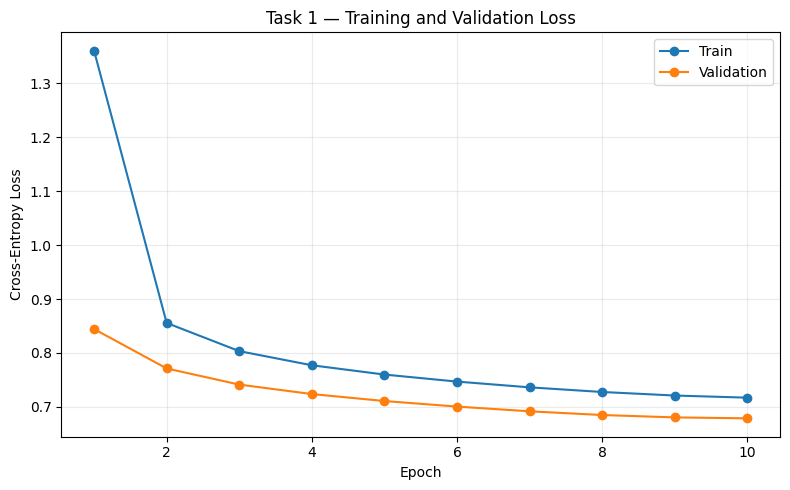

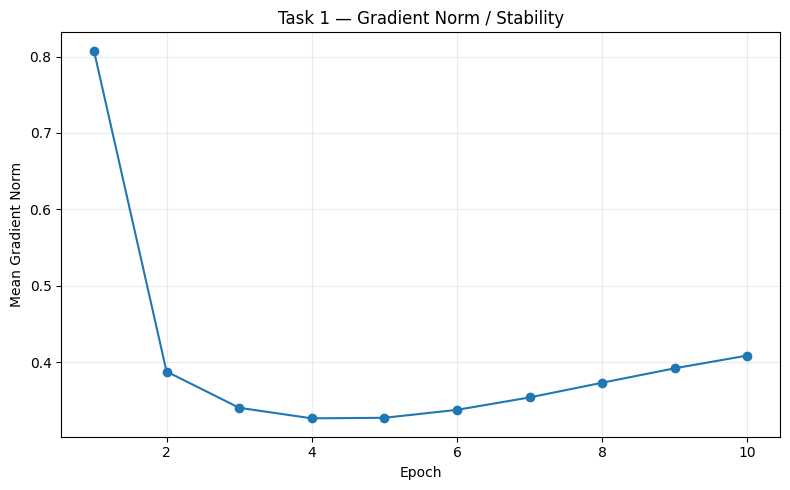

In [20]:
history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Task 1 — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["mean_grad_norm"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Mean Gradient Norm")
plt.title("Task 1 — Gradient Norm / Stability")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gradient_norm.png", dpi=150)
plt.show()

## 15. Load best model and run final train/validation evaluation

In [21]:
best_ckpt = load_checkpoint(BEST_CKPT)
model.eval()

final_train_metrics = evaluate(
    model,
    train_loader,
    max_batches=CFG.eval_batches
)

final_val_metrics = evaluate(
    model,
    val_loader,
    max_batches=None
)

print("Train:", final_train_metrics)
print("Validation:", final_val_metrics)

Loaded checkpoint: epoch=9, batch=5467, global_step=54680
Train: {'loss': 0.6758382964134216, 'accuracy': 0.783616943359375, 'tokens': 1638400}
Validation: {'loss': 0.6852187773409796, 'accuracy': 0.7813322168523099, 'tokens': 8951936}


## 16. Greedy and temperature generation

In [22]:
def encode_text(text):
    ids = [char_to_idx[c] for c in text if c in char_to_idx]
    if not ids:
        raise ValueError("Prompt has no known characters.")
    return torch.tensor(ids, dtype=torch.long, device=device)[None, :]

def decode_ids(ids):
    return "".join(idx_to_char[int(i)] for i in ids)

@torch.no_grad()
def generate(
    model,
    prompt,
    max_new_tokens=500,
    temperature=0.8,
    top_k=40,
    greedy=False,
):
    model.eval()
    idx = encode_text(prompt)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.time()

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -CFG.block_size:]

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits, _ = model(idx_cond)

        logits = logits[:, -1, :]

        if greedy:
            next_idx = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / max(temperature, 1e-6)

            if top_k is not None:
                k = min(top_k, logits.size(-1))
                values, _ = torch.topk(logits, k)
                cutoff = values[:, [-1]]
                logits = torch.where(
                    logits < cutoff,
                    torch.full_like(logits, float("-inf")),
                    logits
                )

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

        idx = torch.cat([idx, next_idx], dim=1)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return {
        "text": decode_ids(idx[0].tolist()),
        "generated_tokens": max_new_tokens,
        "seconds": elapsed,
        "generation_tokens_per_sec": max_new_tokens / elapsed,
    }

## 17. Generate multiple samples

In [23]:
prompts = [
    "Once upon a time",
    "One day, a little girl",
    "There was a small dragon",
    "Tom went to the forest",
    "In a tiny village",
]

samples = []

for prompt in prompts:
    greedy_result = generate(
        model,
        prompt,
        max_new_tokens=CFG.generation_max_new_tokens,
        greedy=True,
    )

    temp_result = generate(
        model,
        prompt,
        max_new_tokens=CFG.generation_max_new_tokens,
        temperature=CFG.temperature,
        top_k=CFG.top_k,
        greedy=False,
    )

    samples.append({
        "prompt": prompt,
        "method": "greedy",
        **greedy_result
    })

    samples.append({
        "prompt": prompt,
        "method": f"temperature_{CFG.temperature}",
        **temp_result
    })

    print("\n" + "=" * 90)
    print("PROMPT:", prompt)
    print("\n--- GREEDY ---\n")
    print(greedy_result["text"])
    print("\n--- TEMPERATURE ---\n")
    print(temp_result["text"])

samples_df = pd.DataFrame(samples)
samples_df.to_csv(OUTPUT_DIR / "generated_samples.csv", index=False)

with open(OUTPUT_DIR / "generated_samples.txt", "w", encoding="utf-8") as f:
    for row in samples:
        f.write("=" * 90 + "\n")
        f.write(f"Prompt: {row['prompt']}\n")
        f.write(f"Method: {row['method']}\n")
        f.write(
            f"Generation tokens/sec: "
            f"{row['generation_tokens_per_sec']:.2f}\n\n"
        )
        f.write(row["text"] + "\n\n")


PROMPT: Once upon a time

--- GREEDY ---

Once upon a time, there was a little girl named Lily. She loved to play outside in the sun. One day, she saw a big box in the garden. It was a big box with a big box of colors. She wanted to make a colorful box of colors. She wanted to make a colorful colorful colors and show her mom the colors. She wanted to make a colorful colorful colors and show her mom the colors. She wanted to make a colorful colorful colors and show her mom the colors. She wanted to make a colorful colorful colors and show her mom the co

--- TEMPERATURE ---

Once upon a time, there was a little girl named Lily. She had a playful doll named Spot. Spot loved to play outside in his garden. One day, something amazing happened. When he was finished, a little girl named Lily saw the magical tree and wanted to go out and explore it. She ran to her mom and asked her to go home and play with her toys.

Her mom understood and told her to help. "Be careful, Lily, it's time to go 

## 18. Distinct-1/2/3 and repeated 4-gram rate

In [24]:
def make_ngrams(seq, n):
    return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]

def distinct_n(text, n):
    grams = make_ngrams(list(text), n)
    return len(set(grams)) / len(grams) if grams else 0.0

def repeated_ngram_rate(text, n=4):
    grams = make_ngrams(list(text), n)
    if not grams:
        return 0.0

    counts = Counter(grams)
    repeated_occurrences = sum(
        count - 1 for count in counts.values() if count > 1
    )
    return repeated_occurrences / len(grams)

rows = []

for row in samples:
    continuation = row["text"][len(row["prompt"]):]

    rows.append({
        "prompt": row["prompt"],
        "method": row["method"],
        "distinct_1": distinct_n(continuation, 1),
        "distinct_2": distinct_n(continuation, 2),
        "distinct_3": distinct_n(continuation, 3),
        "repeated_4gram_rate": repeated_ngram_rate(continuation, 4),
        "generation_tokens_per_sec": row["generation_tokens_per_sec"],
    })

generation_metrics_df = pd.DataFrame(rows)
display(generation_metrics_df)

generation_metrics_df.to_csv(
    OUTPUT_DIR / "generation_metrics.csv",
    index=False
)

,prompt,method,distinct_1,distinct_2,distinct_3,repeated_4gram_rate,generation_tokens_per_sec
0,Once upon a time,greedy,0.060,0.228457,0.313253,0.643863,431.906183
1,Once upon a time,temperature_0.8,0.078,0.374749,0.660643,0.221328,351.892278
2,"One day, a little girl",greedy,0.064,0.254509,0.409639,0.482897,483.206285
3,"One day, a little girl",temperature_0.8,0.076,0.416834,0.720884,0.150905,405.605107
4,There was a small dragon,greedy,0.066,0.308617,0.471888,0.436620,459.526877
5,There was a small dragon,temperature_0.8,0.080,0.394790,0.672691,0.185111,402.880628
6,Tom went to the forest,greedy,0.058,0.256513,0.421687,0.486922,468.445858
7,Tom went to the forest,temperature_0.8,0.068,0.338677,0.608434,0.239437,356.339737
8,In a tiny village,greedy,0.060,0.260521,0.395582,0.541247,465.270114
9,In a tiny village,temperature_0.8,0.070,0.368737,0.642570,0.207243,415.864116


## 19. Final `metrics_report.csv`

In [31]:
best_history_row = min(history, key=lambda r: r["val_loss"])

metrics_report = {
    "training_cross_entropy_loss": final_train_metrics["loss"],
    "validation_cross_entropy_loss": final_val_metrics["loss"],

    "perplexity":
        math.exp(min(final_val_metrics["loss"], 20)),

    "bits_per_character":
        final_val_metrics["loss"] / math.log(2),

    "generalization_gap":
        final_val_metrics["loss"] - final_train_metrics["loss"],

    "top1_next_character_accuracy":
        final_val_metrics["accuracy"],

    "distinct_1_mean":
        generation_metrics_df["distinct_1"].mean(),

    "distinct_2_mean":
        generation_metrics_df["distinct_2"].mean(),

    "distinct_3_mean":
        generation_metrics_df["distinct_3"].mean(),

    "repeated_4gram_rate_mean":
        generation_metrics_df["repeated_4gram_rate"].mean(),

    "mean_gradient_norm_best_epoch":
        best_history_row["mean_grad_norm"],

    "max_gradient_norm_best_epoch":
        best_history_row["max_grad_norm"],

    # No non-finite losses occurred.
    # These events correspond to non-finite gradient norms detected during AMP training.
    "nonfinite_gradient_events_total":
        int(sum(r["nan_count"] for r in history)),

    "parameter_count":
        param_count,

    "trainable_parameter_count":
        trainable_count,

    "training_tokens_per_sec_best_epoch":
        max(r["train_tokens_per_sec"] for r in history),

    "generation_tokens_per_sec_mean":
        generation_metrics_df["generation_tokens_per_sec"].mean(),

    "peak_memory_mb":
        peak_memory_mb,

    "total_training_time_seconds":
        total_training_time,

    "total_training_time_minutes":
        total_training_time / 60,

    "best_validation_epoch":
        best_history_row["epoch"],
}


metrics_df = pd.DataFrame([
    {
        "metric": metric,
        "value": value
    }
    for metric, value in metrics_report.items()
])

display(metrics_df)

metrics_path = OUTPUT_DIR / "metrics_report.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(f"Saved: {metrics_path}")

,metric,value
0,training_cross_entropy_loss,6.758383e-01
1,validation_cross_entropy_loss,6.852188e-01
2,perplexity,1.984206e+00
3,bits_per_character,9.885617e-01
4,generalization_gap,9.380481e-03
5,top1_next_character_accuracy,7.813322e-01
6,distinct_1_mean,6.800000e-02
7,distinct_2_mean,3.202405e-01
8,distinct_3_mean,5.317269e-01
9,repeated_4gram_rate_mean,3.595573e-01


Saved: /app/task1_llm/Pramod_Dindukurthi/outputs/metrics_report.csv


## 20. Failure-analysis template from actual generated samples

In [32]:
# Final Task 1 failure analysis
failure_analysis_path = OUTPUT_ROOT / "failure_analysis.md"

failure_analysis_text = """# Task 1 — Sequence Model Failure Analysis

Three representative failure cases were selected from the actual generated samples.

## Failure Case 1 — Repetitive Loop

**Prompt:** `Once upon a time`  
**Decoding:** Greedy

**Generated snippet:**

> She wanted to make a colorful colorful colors and show her mom the colors. She wanted to make a colorful colorful colors and show her mom the colors.

**Failure type:** Repetition / degeneration

**Observation:**  
The greedy decoder repeatedly selects the locally highest-probability continuation and becomes trapped in a phrase loop. The sentence remains locally grammatical, but the story stops progressing. This behavior is consistent with the high repeated 4-gram rate observed for greedy decoding.

---

## Failure Case 2 — Entity and Narrative Drift

**Prompt:** `There was a small dragon`  
**Decoding:** Temperature sampling (`temperature=0.8`)

**Generated snippet:**

> There was a small dragon named Daisy... When she found the box, Lily was so happy! "I think it was a fire joke!" Tom said.

**Failure type:** Loss of coherence / character inconsistency

**Observation:**  
The generation starts with Daisy as the main character but unexpectedly introduces Lily and Tom without establishing a relationship between them. Temperature sampling improves diversity, but the added randomness can weaken long-range entity consistency.

---

## Failure Case 3 — Semantic Contradiction and Repetition

**Prompt:** `Tom went to the forest`  
**Decoding:** Greedy

**Generated snippet:**

> It is a bad dog. It is not a bad dog. It is a bad dog. It is bad. It hurts a lot.

**Failure type:** Semantic contradiction / repetition

**Observation:**  
The output contains directly contradictory statements about the dog and repeats similar short clauses. The model captures local TinyStories-style syntax but has limited ability to maintain consistent global meaning over longer generations.

---

## Overall Observation

Greedy decoding produced more deterministic text but was substantially more prone to repeated phrase loops. Temperature sampling at 0.8 increased diversity and reduced repeated 4-grams, but sometimes caused entity drift and weaker semantic consistency. These failures reflect the limited long-range modeling capacity of the small character-level GPT.
"""

failure_analysis_path.write_text(
    failure_analysis_text,
    encoding="utf-8"
)

print("Written:", failure_analysis_path)


Written: /app/task1_llm/Pramod_Dindukurthi/failure_analysis.md


## 21. Generate `results.md` from the actual run

In [34]:
results_path = OUTPUT_ROOT / "results.md"

results_text = f"""# Task 1 — GPT-Style LLM From Scratch

## Architecture

- Character-level autoregressive GPT
- Context length: {CFG.block_size}
- Embedding dimension: {CFG.d_model}
- Attention heads: {CFG.n_heads}
- Transformer blocks: {CFG.n_layers}
- Feed-forward dimension: {CFG.ffn_dim}
- Dropout: {CFG.dropout}
- Parameter count: {param_count:,}

Attention was implemented manually using Q/K/V projections,
scaled dot-product matrix multiplication, and a causal lower-triangular mask.
No prebuilt Transformer or attention module was used.

## Data

- Dataset: TinyStories
- Training stories: {CFG.train_stories:,}
- Validation stories: {CFG.val_stories:,}
- Tokenization: character-level
- Vocabulary size: {vocab_size}
- Sequence length: {CFG.block_size}

## Training

- Epochs: {CFG.epochs}
- Batch size: {CFG.batch_size}
- Gradient accumulation: {CFG.grad_accum_steps}
- Optimizer: AdamW
- Peak learning rate: {CFG.learning_rate}
- LR schedule: linear warm-up + cosine decay
- AMP: {amp_enabled}
- Best validation epoch: {best_history_row["epoch"]}

## Hardware

- GPU: {hardware_manifest["gpu"]}
- PyTorch: {hardware_manifest["pytorch"]}
- CUDA runtime: {hardware_manifest["cuda_runtime"]}

## Final Metrics

| Metric | Value |
|---|---:|
| Train cross-entropy | {metrics_report["training_cross_entropy_loss"]:.4f} |
| Validation cross-entropy | {metrics_report["validation_cross_entropy_loss"]:.4f} |
| Perplexity | {metrics_report["perplexity"]:.3f} |
| Bits per character | {metrics_report["bits_per_character"]:.3f} |
| Generalization gap | {metrics_report["generalization_gap"]:.4f} |
| Top-1 next-character accuracy | {metrics_report["top1_next_character_accuracy"]:.4f} |
| Distinct-1 | {metrics_report["distinct_1_mean"]:.4f} |
| Distinct-2 | {metrics_report["distinct_2_mean"]:.4f} |
| Distinct-3 | {metrics_report["distinct_3_mean"]:.4f} |
| Repeated 4-gram rate | {metrics_report["repeated_4gram_rate_mean"]:.4f} |
| Mean gradient norm (best epoch) | {metrics_report["mean_gradient_norm_best_epoch"]:.4f} |
| Max gradient norm (best epoch) | {metrics_report["max_gradient_norm_best_epoch"]:.4f} |
| Non-finite gradient events | {metrics_report["nonfinite_gradient_events_total"]} |
| Training tokens/sec (best epoch) | {metrics_report["training_tokens_per_sec_best_epoch"]:.1f} |
| Generation tokens/sec | {metrics_report["generation_tokens_per_sec_mean"]:.1f} |
| Peak GPU memory (MB) | {metrics_report["peak_memory_mb"]:.1f} |
| Total training time (min) | {metrics_report["total_training_time_minutes"]:.1f} |

## Generated Samples

See:
- `outputs/generated_samples.txt`
- `outputs/generated_samples.csv`

## Failure Analysis

See `failure_analysis.md`.

## Discussion

The model converged smoothly across all 10 epochs, with validation loss continuing
to improve through the final epoch. The final train and validation losses remained
close, indicating a small generalization gap and no obvious overfitting.

Greedy decoding produced more repetitive outputs and frequently entered repeated
phrase loops. Temperature sampling at 0.8 increased sequence diversity, producing
higher Distinct-1/2/3 scores and substantially lower repeated 4-gram rates, although
it occasionally introduced character drift and semantic inconsistencies.

Training remained stable overall. No non-finite loss events occurred. A small number
of non-finite gradient-norm events were detected during mixed-precision training and
handled by AMP GradScaler without causing training divergence.
"""

results_path.write_text(results_text, encoding="utf-8")

print("Written:", results_path)

Written: /app/task1_llm/Pramod_Dindukurthi/results.md


# 22. Before leaving the GPU lab

Back up at least:

- `config.json`
- `hardware_manifest.json`
- `metrics_report.csv`
- `results.md`
- `failure_analysis.md`
- `outputs/training_history.csv`
- `outputs/loss_curves.png`
- `outputs/gradient_norm.png`
- `outputs/generated_samples.txt`
- `outputs/generated_samples.csv`
- `outputs/generation_metrics.csv`
- `logs/training_log.txt`
- `checkpoints/best_model.pt`
- `checkpoints/latest_checkpoint.pt`

Large checkpoints do not necessarily belong in normal Git history; copy them to persistent storage.



In [35]:
!find /app/task1_llm/Pramod_Dindukurthi -maxdepth 2 -type f -exec ls -lh {} \; | sort

-rw-r--r-- 1 root root 1.3K Oct  6 04:03 /app/task1_llm/Pramod_Dindukurthi/outputs/generation_metrics.csv
-rw-r--r-- 1 root root 171M Oct  6 03:06 /app/task1_llm/Pramod_Dindukurthi/data_processed/train_ids.pt
-rw-r--r-- 1 root root 18M Oct  6 03:06 /app/task1_llm/Pramod_Dindukurthi/data_processed/val_ids.pt
-rw-r--r-- 1 root root 2.5K Oct  6 04:22 /app/task1_llm/Pramod_Dindukurthi/results.md
-rw-r--r-- 1 root root 2.6K Oct  6 03:23 /app/task1_llm/Pramod_Dindukurthi/data_processed/vocab.json
-rw-r--r-- 1 root root 2.6K Oct  6 03:52 /app/task1_llm/Pramod_Dindukurthi/outputs/training_history.csv
-rw-r--r-- 1 root root 300 Oct  6 03:21 /app/task1_llm/Pramod_Dindukurthi/hardware_manifest.json
-rw-r--r-- 1 root root 37M Oct  6 03:34 /app/task1_llm/Pramod_Dindukurthi/checkpoints/smoke_checkpoint.pt
-rw-r--r-- 1 root root 37M Oct  6 03:38 /app/task1_llm/Pramod_Dindukurthi/checkpoints/checkpoint_step_0005000.pt
-rw-r--r-- 1 root root 37M Oct  6 03:39 /app/task1_llm/Pramod_Dindukurthi/checkpoint